  URT–RMHD PLASMA SUPER-CELL
[INFO] Grid: 128x128, steps=2000, dt=5.00e-04
[INFO] nu=1.0e-04, eta=1.0e-04, Hall=True, pressure=True
[INFO] k_URT_omega=0.500, k_URT_A=0.300
-----------------------------------------------------------
step=    0, t=0.0000, δ_ω=1.12394, δ_A=0.47719, |δ_ω-δ*|=9.764e-01, E=3.7954e-02
step=   50, t=0.0250, δ_ω=1.04835, δ_A=1.04835, |δ_ω-δ*|=9.008e-01, E=7.6633e+07
step=  100, t=0.0500, δ_ω=1.05405, δ_A=1.05405, |δ_ω-δ*|=9.065e-01, E=7.6508e+07
step=  150, t=0.0750, δ_ω=1.04553, δ_A=1.04553, |δ_ω-δ*|=8.980e-01, E=7.6693e+07
step=  200, t=0.1000, δ_ω=1.04822, δ_A=1.04822, |δ_ω-δ*|=9.007e-01, E=7.6631e+07
step=  250, t=0.1250, δ_ω=1.04627, δ_A=1.04627, |δ_ω-δ*|=8.987e-01, E=7.6674e+07
step=  300, t=0.1500, δ_ω=1.04863, δ_A=1.04863, |δ_ω-δ*|=9.011e-01, E=7.6627e+07
step=  350, t=0.1750, δ_ω=1.05103, δ_A=1.05103, |δ_ω-δ*|=9.035e-01, E=7.6570e+07
step=  400, t=0.2000, δ_ω=1.05680, δ_A=1.05680, |δ_ω-δ*|=9.093e-01, E=7.6446e+07
step=  450, t=0.2250, δ_ω=1.04957, δ_A=

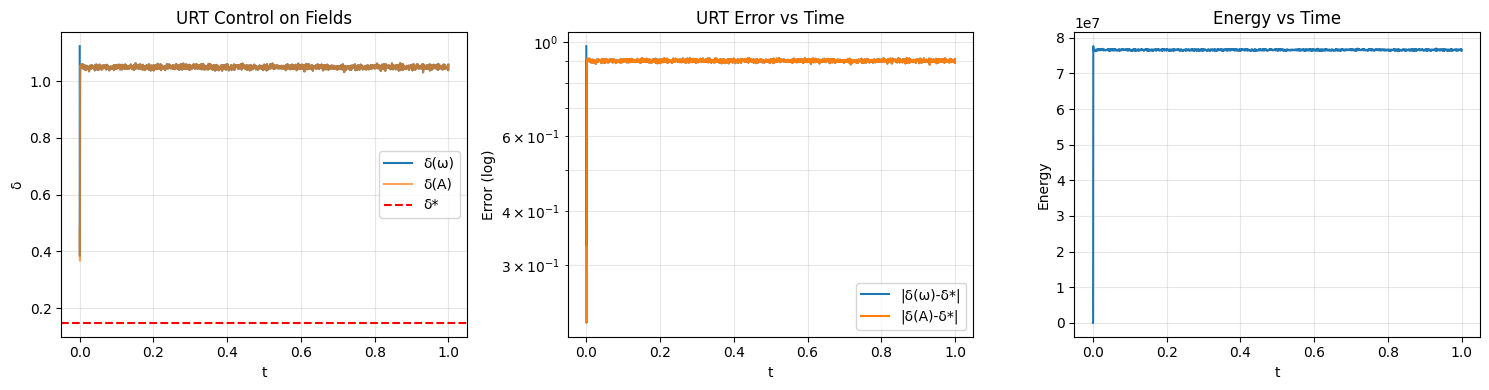

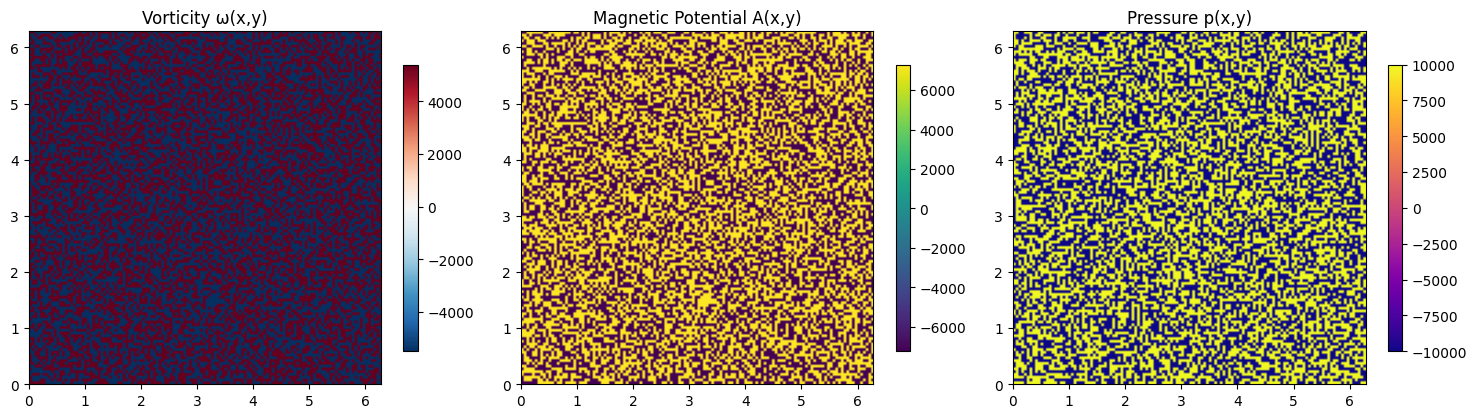

In [1]:
"""
URT–RMHD PLASMA SUPER-CELL (CLEAN CORE)
======================================

- 2D reduced-MHD–style plasma with periodic BCs
- Optional pressure and Hall-like correction
- URT control on vorticity δ(ω) -> δ* = 0.14752
- RK4 time integrator + spectral Poisson solver
- Designed to be simple, robust, and Colab-friendly

Author: Cornelius Lytollis (concept) + ChatGPT (implementation)
Date:   November 2025
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GLOBAL CONSTANTS / CONFIG
# ============================================================

# Chaos-field constants
DELTA_STAR      = 0.14752   # Target URT ground state
K_URT_OMEGA     = 0.5       # URT gain on vorticity
K_URT_A         = 0.3       # Optional URT gain on magnetic potential
MAX_FIELD_ABS   = 1e4       # Safety clip for all fields

# Grid / domain (you can bump NX, NY in Colab if you have RAM)
NX, NY = 128, 128
LX, LY = 2.0 * np.pi, 2.0 * np.pi
DX, DY = LX / NX, LY / NY

# Time integration
DT           = 5e-4         # Time step
NSTEPS       = 2000         # Number of steps
REPORT_EVERY = 50           # Diagnostic print interval

# Diffusion (viscosity & resistivity)
NU  = 1e-4                  # Viscosity
ETA = 1e-4                  # Resistivity

# Extra physics switches
INCLUDE_PRESSURE = True
KAPPA_P          = 1e-4     # Pressure diffusion
BETA_P           = 0.1      # p–A coupling into ω (toy β-effect)

INCLUDE_HALL     = True
D_I              = 0.1      # Hall "ion skin depth" scale (toy)

# ============================================================
# FOURIER HELPERS FOR POISSON SOLVES
# ============================================================

# Wavenumbers for spectral Poisson solve (periodic)
kx = np.fft.fftfreq(NX, d=DX) * 2.0 * np.pi
ky = np.fft.fftfreq(NY, d=DY) * 2.0 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing="ij")
K2 = KX**2 + KY**2
K2_safe = K2.copy()
K2_safe[0, 0] = 1.0  # avoid division by zero at k=0


def phi_from_omega(omega):
    """
    Solve ∇² φ = ω in Fourier space: φ_hat = -ω_hat / k^2
    (zero out k=0 mode).
    """
    omega_hat = np.fft.fft2(omega)
    phi_hat = -omega_hat / K2_safe
    phi_hat[0, 0] = 0.0
    phi = np.fft.ifft2(phi_hat).real
    return phi


def J_from_A(A):
    """
    Current density J = -∇² A via spectral Laplacian.
    """
    A_hat = np.fft.fft2(A)
    J_hat = -K2 * A_hat
    J = np.fft.ifft2(J_hat).real
    return J

# ============================================================
# FINITE-DIFFERENCE OPERATORS (PERIODIC)
# ============================================================

def ddx(f):
    """Periodic ∂f/∂x using centered finite differences."""
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2.0 * DX)


def ddy(f):
    """Periodic ∂f/∂y using centered finite differences."""
    return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2.0 * DY)


def laplacian(f):
    """Periodic 2D Laplacian using 5-point stencil."""
    return (
        np.roll(f, -1, axis=0) + np.roll(f, 1, axis=0) +
        np.roll(f, -1, axis=1) + np.roll(f, 1, axis=1) -
        4.0 * f
    ) / (DX * DX)


def bracket(f, g):
    """
    Poisson bracket [f, g] = ∂x f ∂y g - ∂y f ∂x g
    """
    fx = ddx(f)
    fy = ddy(f)
    gx = ddx(g)
    gy = ddy(g)
    return fx * gy - fy * gx

# ============================================================
# URT DELTA MEASUREMENT & CONTROL
# ============================================================

def measure_delta(field):
    """
    URT-style delta:
      δ = mean(|nearest-neighbour increments|) / std(field)
    """
    inc_x = np.abs(np.roll(field, -1, axis=0) - field)
    inc_y = np.abs(np.roll(field, -1, axis=1) - field)
    inc = 0.5 * (inc_x + inc_y)
    short_range = inc.mean()
    long_range = field.std()
    if long_range < 1e-12:
        return 0.0
    return float(short_range / long_range)


def urt_apply_global(field, k_gain):
    """
    Global URT control on a scalar field to drive δ(field) → δ*.

    Returns:
        field_new, delta_before, error_before
    """
    delta = measure_delta(field)
    err = delta - DELTA_STAR

    # Global feedback: rescale fluctuations about the mean
    u = -k_gain * err
    u = float(np.clip(u, -0.5, 0.5))  # avoid over-aggressive control

    mean_f = field.mean()
    fluct = field - mean_f
    field_new = mean_f + (1.0 + u) * fluct

    # Safety clip
    field_new = np.clip(field_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return field_new, delta, err

# ============================================================
# ENERGY DIAGNOSTIC
# ============================================================

def compute_energy(omega, A, p=None):
    """
    Simple energy-like diagnostic:
      E = 1/2 <φ^2 + A^2 + p^2>  (p optional)
    """
    phi = phi_from_omega(omega)
    E = 0.5 * np.mean(phi**2 + A**2)
    if p is not None:
        E += 0.5 * np.mean(p**2)
    return float(E)

# ============================================================
# RHS OF REDUCED-MHD–STYLE EQUATIONS
# ============================================================

def rhs(omega, A, p):
    """
    Compute RHS for (ω, A, p):

      ∂t ω = -[φ, ω] + [J, A] + ν ∇² ω + β_p [p, A]   (if pressure present)
      ∂t A = -[φ, A] - d_i [J, A] + η ∇² A           (if Hall enabled)
      ∂t p = -[φ, p] + κ_p ∇² p                      (if pressure present)

    with:
      φ from ∇² φ = ω,
      J = -∇² A.
    """
    phi = phi_from_omega(omega)
    J = J_from_A(A)

    # Vorticity equation
    adv_ω = -bracket(phi, omega) + bracket(J, A)
    rhs_ω = adv_ω + NU * laplacian(omega)

    # Magnetic potential equation
    adv_A = -bracket(phi, A)
    if INCLUDE_HALL:
        adv_A += -D_I * bracket(J, A)
    rhs_A = adv_A + ETA * laplacian(A)

    # Pressure equation (optional)
    rhs_p = None
    if (p is not None) and INCLUDE_PRESSURE:
        adv_p = -bracket(phi, p)
        rhs_p = adv_p + KAPPA_P * laplacian(p)
        # Couple pressure back into vorticity as a simple β-effect
        rhs_ω += BETA_P * bracket(p, A)

    return rhs_ω, rhs_A, rhs_p

# ============================================================
# RK4 TIME STEPPER
# ============================================================

def rk4_step(omega, A, p, dt):
    # k1
    k1_ω, k1_A, k1_p = rhs(omega, A, p)

    # k2
    if k1_p is None:
        p_k2 = None
    else:
        p_k2 = p + 0.5 * dt * k1_p
    k2_ω, k2_A, k2_p = rhs(
        omega + 0.5 * dt * k1_ω,
        A     + 0.5 * dt * k1_A,
        p_k2
    )

    # k3
    if k2_p is None:
        p_k3 = None
    else:
        p_k3 = p + 0.5 * dt * k2_p
    k3_ω, k3_A, k3_p = rhs(
        omega + 0.5 * dt * k2_ω,
        A     + 0.5 * dt * k2_A,
        p_k3
    )

    # k4
    if k3_p is None:
        p_k4 = None
    else:
        p_k4 = p + dt * k3_p
    k4_ω, k4_A, k4_p = rhs(
        omega + dt * k3_ω,
        A     + dt * k3_A,
        p_k4
    )

    omega_new = omega + (dt / 6.0) * (k1_ω + 2.0 * k2_ω + 2.0 * k3_ω + k4_ω)
    A_new     = A     + (dt / 6.0) * (k1_A + 2.0 * k2_A + 2.0 * k3_A + k4_A)

    if k1_p is None:
        p_new = None
    else:
        p_new = p + (dt / 6.0) * (k1_p + 2.0 * k2_p + 2.0 * k3_p + k4_p)

    # Safety clips
    omega_new = np.clip(omega_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)
    A_new     = np.clip(A_new,     -MAX_FIELD_ABS, MAX_FIELD_ABS)
    if p_new is not None:
        p_new = np.clip(p_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return omega_new, A_new, p_new

# ============================================================
# INITIAL CONDITIONS
# ============================================================

def initial_conditions(seed=42):
    """
    Random vorticity + magnetic potential + optional pressure,
    plus a smooth Gaussian bump in A to seed structure.
    """
    rng = np.random.default_rng(seed)

    omega = 0.1 * rng.standard_normal((NX, NY))
    A     = 0.1 * rng.standard_normal((NX, NY))

    # Pressure field (optional)
    if INCLUDE_PRESSURE:
        p = 0.05 * rng.standard_normal((NX, NY))
    else:
        p = None

    # Add a smooth Gaussian bump in A to seed a magnetic island
    x = np.linspace(0, LX, NX, endpoint=False)
    y = np.linspace(0, LY, NY, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing="ij")

    cx, cy = 0.5 * LX, 0.5 * LY
    r2 = (X - cx)**2 + (Y - cy)**2
    A += 1.0 * np.exp(-r2 / (0.2 * LX)**2)

    return omega, A, p

# ============================================================
# MAIN SUPER-CELL SIMULATION
# ============================================================

def run_supercell():
    omega, A, p = initial_conditions()

    t = 0.0
    history = {
        "t": [],
        "delta_omega": [],
        "delta_A": [],
        "energy": [],
        "err_omega": [],
        "err_A": [],
    }

    print("===========================================================")
    print("  URT–RMHD PLASMA SUPER-CELL")
    print("===========================================================")
    print(f"[INFO] Grid: {NX}x{NY}, steps={NSTEPS}, dt={DT:.2e}")
    print(f"[INFO] nu={NU:.1e}, eta={ETA:.1e}, "
          f"Hall={INCLUDE_HALL}, pressure={INCLUDE_PRESSURE}")
    print(f"[INFO] k_URT_omega={K_URT_OMEGA:.3f}, k_URT_A={K_URT_A:.3f}")
    print("-----------------------------------------------------------")

    for step in range(NSTEPS + 1):

        # Diagnostics BEFORE PDE + URT step
        delta_ω = measure_delta(omega)
        delta_A = measure_delta(A)
        E       = compute_energy(omega, A, p)
        err_ω   = abs(delta_ω - DELTA_STAR)
        err_A   = abs(delta_A - DELTA_STAR)

        history["t"].append(t)
        history["delta_omega"].append(delta_ω)
        history["delta_A"].append(delta_A)
        history["energy"].append(E)
        history["err_omega"].append(err_ω)
        history["err_A"].append(err_A)

        if step % REPORT_EVERY == 0:
            print(
                f"step={step:5d}, t={t:6.4f}, "
                f"δ_ω={delta_ω:.5f}, δ_A={delta_A:.5f}, "
                f"|δ_ω-δ*|={err_ω:.3e}, E={E:.4e}"
            )

        if step == NSTEPS:
            break

        # --- 1) RMHD / Hall / pressure physics (RK4) ---
        omega, A, p = rk4_step(omega, A, p, DT)
        t += DT

        # --- 2) URT control steps ---
        omega, _, _ = urt_apply_global(omega, K_URT_OMEGA)
        A, _, _     = urt_apply_global(A,     K_URT_A)

        # --- 3) NaN safety check ---
        if (not np.isfinite(omega).all() or
            not np.isfinite(A).all() or
            (p is not None and not np.isfinite(p).all())):
            print("NaN or Inf detected, stopping early at step", step)
            break

    print("===========================================================")
    print("  Simulation complete.")
    print("===========================================================")

    return omega, A, p, history

# ============================================================
# PLOTTING UTILITIES
# ============================================================

def plot_history(history):
    t     = np.array(history["t"])
    delta = np.array(history["delta_omega"])
    deltaA = np.array(history["delta_A"])
    E     = np.array(history["energy"])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    ax.plot(t, delta, label="δ(ω)")
    ax.plot(t, deltaA, label="δ(A)", alpha=0.7)
    ax.axhline(DELTA_STAR, color="r", linestyle="--", label="δ*")
    ax.set_xlabel("t")
    ax.set_ylabel("δ")
    ax.set_title("URT Control on Fields")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogy(t, np.abs(delta - DELTA_STAR) + 1e-16, label="|δ(ω)-δ*|")
    ax.semilogy(t, np.abs(deltaA - DELTA_STAR) + 1e-16, label="|δ(A)-δ*|")
    ax.set_xlabel("t")
    ax.set_ylabel("Error (log)")
    ax.set_title("URT Error vs Time")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

    ax = axes[2]
    ax.plot(t, E)
    ax.set_xlabel("t")
    ax.set_ylabel("Energy")
    ax.set_title("Energy vs Time")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_fields(omega, A, p=None):
    ncols = 3 if p is not None else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4))

    im0 = axes[0].imshow(omega.T, origin="lower", cmap="RdBu_r",
                         extent=[0, LX, 0, LY])
    axes[0].set_title("Vorticity ω(x,y)")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(A.T, origin="lower", cmap="viridis",
                         extent=[0, LX, 0, LY])
    axes[1].set_title("Magnetic Potential A(x,y)")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    if p is not None:
        im2 = axes[2].imshow(p.T, origin="lower", cmap="plasma",
                             extent=[0, LX, 0, LY])
        axes[2].set_title("Pressure p(x,y)")
        plt.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.show()

# ============================================================
# RUN IF MAIN (COLAB-FRIENDLY)
# ============================================================

if __name__ == "__main__":
    omega_f, A_f, p_f, hist = run_supercell()
    plot_history(hist)
    plot_fields(omega_f, A_f, p_f)

In [ ]:
"""
URT–RMHD 2.5D SUPER CELL (ω, A, p) – CLEAN CORE
===============================================
- 2.5D reduced-MHD–style toy plasma with periodic x,y and stacked planes in z
- URT control on:
    * vorticity ω   -> δ_ω  -> δ* = 0.14752
    * magnetic A    -> δ_A  -> δ* = 0.14752
    * pressure p    -> δ_p  -> δ* = 0.14752
- Hall-like coupling, perpendicular & parallel transport
- RK4 time integrator
- Designed to be simple, robust, and Colab-friendly (pure NumPy)

Author: Cornelius Lytollis (concept) + ChatGPT (implementation)
Date:   November 2025
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GLOBAL CONSTANTS / PARAMETERS
# ============================================================

# Chaos-field targets (same for all three here, but you can split them)
DELTA_STAR_OMEGA = 0.14752
DELTA_STAR_A     = 0.14752
DELTA_STAR_P     = 0.14752

# URT gains
K_URT_OMEGA = 0.5
K_URT_A     = 0.4
K_URT_P     = 0.3

MAX_FIELD_ABS = 1e4      # safety clip

# Geometry / grid
GEOMETRY = "cartesian"   # options: "cartesian", "toroidal" (toy metric)
NX, NY, NZ = 128, 128, 4    # 2.5D: stacked planes in z

LX, LY, LZ = 2.0*np.pi, 2.0*np.pi, 1.0
DX, DY, DZ = LX/NX, LY/NY, LZ/NZ

# Time integration
DT      = 5e-4
NSTEPS  = 2000
REPORT_EVERY = 50

# Diffusion / transport / Hall-like parameters
NU_PERP   = 1e-4      # viscosity (x,y)
NU_PAR    = 1e-4      # viscosity along z
ETA_PERP  = 1e-4      # resistivity (x,y)
ETA_PAR   = 1e-4      # resistivity along z
CHI_PERP  = 5e-4      # pressure diffusion (x,y)
CHI_PAR   = 5e-4      # pressure diffusion along z
D_I       = 0.1       # Hall-like coefficient (toy)

# ============================================================
# FOURIER HELPERS FOR PLANE-BY-PLANE POISSON SOLVE
# ============================================================

kx = np.fft.fftfreq(NX, d=DX) * 2.0 * np.pi
ky = np.fft.fftfreq(NY, d=DY) * 2.0 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing="ij")
K2 = KX**2 + KY**2
K2_safe = K2.copy()
K2_safe[0, 0] = 1.0

# Toy R-metric for "toroidal" geometry
x_grid = np.linspace(0, LX, NX, endpoint=False)
y_grid = np.linspace(0, LY, NY, endpoint=False)
XG, YG = np.meshgrid(x_grid, y_grid, indexing="ij")
R0 = 3.0
R = R0 + (XG - LX/2.0)  # major radius approx


def geometry_factor():
    """Return metric factor g(x,y) for geometry."""
    if GEOMETRY == "toroidal":
        return 1.0 / np.maximum(R, 0.5)  # simple 1/R weight
    else:
        return np.ones_like(R)


G_METRIC = geometry_factor()

# ============================================================
# FINITE-DIFFERENCE OPERATORS (PERIODIC in x,y,z)
# ============================================================

def ddx(f):
    """Periodic ∂f/∂x using centered finite differences (acts on [x,y,z])."""
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2.0 * DX)

def ddy(f):
    """Periodic ∂f/∂y using centered finite differences (acts on [x,y,z])."""
    return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2.0 * DY)

def ddz(f):
    """Periodic ∂f/∂z using centered finite differences (acts on [x,y,z])."""
    return (np.roll(f, -1, axis=2) - np.roll(f, 1, axis=2)) / (2.0 * DZ)

def laplacian_xy(f):
    """2D Laplacian in x,y for 3D array f(x,y,z)."""
    return (
        np.roll(f, -1, axis=0) + np.roll(f, 1, axis=0) +
        np.roll(f, -1, axis=1) + np.roll(f, 1, axis=1) -
        4.0 * f
    ) / (DX*DX)

def laplacian_z(f):
    """Second derivative along z (1D Laplacian)."""
    return (
        np.roll(f, -1, axis=2) + np.roll(f, 1, axis=2) -
        2.0 * f
    ) / (DZ*DZ)

def bracket(f, g):
    """
    Poisson bracket [f, g] = ∂x f ∂y g - ∂y f ∂x g
    Acts on 3D arrays but derivatives only in x,y.
    """
    fx = ddx(f)
    fy = ddy(f)
    gx = ddx(g)
    gy = ddy(g)
    return fx*gy - fy*gx

# ============================================================
# PLANE-BY-PLANE POISSON SOLVES
# ============================================================

def phi_from_omega(omega):
    """
    Solve ∇² φ = ω in each z-plane via FFT.
    """
    phi = np.empty_like(omega)
    for k in range(NZ):
        w_plane = omega[:, :, k]
        w_hat   = np.fft.fft2(w_plane)
        phi_hat = -w_hat / K2_safe
        phi_hat[0, 0] = 0.0
        phi[:, :, k] = np.fft.ifft2(phi_hat).real
    return phi

def J_from_A(A):
    """
    Current density J = -∇² A in each z-plane via FFT.
    """
    J = np.empty_like(A)
    for k in range(NZ):
        A_hat = np.fft.fft2(A[:, :, k])
        J_hat = -K2 * A_hat
        J[:, :, k] = np.fft.ifft2(J_hat).real
    return J

# ============================================================
# URT DELTA MEASUREMENT & CONTROL (3D)
# ============================================================

def measure_delta(field):
    """
    URT-style delta over 3D field:
      δ = mean(|nearest-neighbour increments|) / std(field)
    increments taken along x,y,z.
    """
    inc_x = np.abs(np.roll(field, -1, axis=0) - field)
    inc_y = np.abs(np.roll(field, -1, axis=1) - field)
    inc_z = np.abs(np.roll(field, -1, axis=2) - field)
    inc = (inc_x + inc_y + inc_z) / 3.0
    short_range = inc.mean()
    long_range  = field.std()
    if long_range < 1e-12:
        return 0.0
    return float(short_range / long_range)

def urt_update(field, delta_star, gain):
    """
    Apply global URT control to a 3D field to drive δ(field) → δ*.
    """
    delta = measure_delta(field)
    err   = delta - delta_star
    u     = -gain * err
    u     = float(np.clip(u, -0.5, 0.5))  # avoid crazy rescaling

    mean_f  = field.mean()
    fluct   = field - mean_f
    field_n = mean_f + (1.0 + u)*fluct

    field_n = np.clip(field_n, -MAX_FIELD_ABS, MAX_FIELD_ABS)
    return field_n, delta, err

# ============================================================
# ENERGY DIAGNOSTIC
# ============================================================

def compute_energy(omega, A, p):
    """
    Simple global energy-like diagnostic:
      E = 1/2 < |∇φ|^2 + |B|^2 + α p^2 >
    with φ from ∇² φ = ω and B = ∇×(A e_z) in x,y.
    """
    phi = phi_from_omega(omega)

    # ExB velocities (approx)
    vx = -ddy(phi)
    vy =  ddx(phi)

    # Magnetic field from A (Bx = -∂A/∂y, By = ∂A/∂x)
    Bx = -ddy(A)
    By =  ddx(A)

    v2 = vx**2 + vy**2
    B2 = Bx**2 + By**2
    E  = 0.5 * np.mean(v2 + B2 + 0.1*p**2)

    return float(E)

# ============================================================
# RHS OF 2.5D RMHD-HALL-PRESSURE SYSTEM
# ============================================================

def rhs_all(omega, A, p):
    """
    Compute RHS for ω, A, p in 2.5D:

      ∂t ω = -[φ, ω] + [J, A] + ν_⊥ ∇²_⊥ ω + ν_∥ ∂²_z ω
      ∂t A = -[φ, A] + d_i [J, A] + η_⊥ ∇²_⊥ A + η_∥ ∂²_z A
      ∂t p = -[φ, p] + χ_⊥ ∇²_⊥ p + χ_∥ ∂²_z p

    with:
      φ from ∇² φ = ω,
      J = -∇² A (FFT-based),
      geometry weighting entering as a simple multiplicative factor on Laplacians.
    """
    phi = phi_from_omega(omega)
    J   = J_from_A(A)

    # Poisson brackets (advection terms)
    adv_omega = -bracket(phi, omega) + bracket(A, J)
    adv_A     = -bracket(phi, A)
    adv_p     = -bracket(phi, p)

    # Diffusion / transport (perp and parallel)
    lap_omega_xy = laplacian_xy(omega)
    lap_A_xy     = laplacian_xy(A)
    lap_p_xy     = laplacian_xy(p)

    lap_omega_z  = laplacian_z(omega)
    lap_A_z      = laplacian_z(A)
    lap_p_z      = laplacian_z(p)

    # Geometry weighting (toy R-metric)
    lap_omega_xy *= G_METRIC[:, :, None]
    lap_A_xy     *= G_METRIC[:, :, None]
    lap_p_xy     *= G_METRIC[:, :, None]

    rhs_omega = (
        adv_omega +
        NU_PERP * lap_omega_xy +
        NU_PAR  * lap_omega_z
    )

    # Add Hall-like term to A using J×B ~ [J, A] (toy)
    hall_term = D_I * bracket(J, A)

    rhs_A = (
        adv_A +
        hall_term +
        ETA_PERP * lap_A_xy +
        ETA_PAR  * lap_A_z
    )

    rhs_p = (
        adv_p +
        CHI_PERP * lap_p_xy +
        CHI_PAR  * lap_p_z
    )

    return rhs_omega, rhs_A, rhs_p

# ============================================================
# RK4 STEPPER
# ============================================================

def rk4_step_all(omega, A, p, dt):
    k1_ω, k1_A, k1_p = rhs_all(omega, A, p)

    k2_ω, k2_A, k2_p = rhs_all(
        omega + 0.5*dt*k1_ω,
        A     + 0.5*dt*k1_A,
        p     + 0.5*dt*k1_p,
    )
    k3_ω, k3_A, k3_p = rhs_all(
        omega + 0.5*dt*k2_ω,
        A     + 0.5*dt*k2_A,
        p     + 0.5*dt*k2_p,
    )
    k4_ω, k4_A, k4_p = rhs_all(
        omega + dt*k3_ω,
        A     + dt*k3_A,
        p     + dt*k3_p,
    )

    omega_n = omega + (dt/6.0)*(k1_ω + 2.0*k2_ω + 2.0*k3_ω + k4_ω)
    A_n     = A     + (dt/6.0)*(k1_A + 2.0*k2_A + 2.0*k3_A + k4_A)
    p_n     = p     + (dt/6.0)*(k1_p + 2.0*k2_p + 2.0*k3_p + k4_p)

    # Safety clip
    omega_n = np.clip(omega_n, -MAX_FIELD_ABS, MAX_FIELD_ABS)
    A_n     = np.clip(A_n,     -MAX_FIELD_ABS, MAX_FIELD_ABS)
    p_n     = np.clip(p_n,     -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return omega_n, A_n, p_n

# ============================================================
# INITIAL CONDITIONS
# ============================================================

def initial_conditions(seed=42):
    rng = np.random.default_rng(seed)

    # Random noise fields
    omega = 0.1 * rng.standard_normal((NX, NY, NZ))
    A     = 0.1 * rng.standard_normal((NX, NY, NZ))
    p     = 0.1 * rng.standard_normal((NX, NY, NZ))

    # Add a magnetic island bump in A in all planes
    cx, cy = LX/2.0, LY/2.0
    r2 = (XG - cx)**2 + (YG - cy)**2
    bump = np.exp(-r2 / (0.2*LX)**2)
    for k in range(NZ):
        A[:, :, k] += bump

    # Add a pressure gradient along x
    for k in range(NZ):
        p[:, :, k] += 0.5*(XG/LX - 0.5)

    return omega, A, p

# ============================================================
# MAIN SIMULATION DRIVER
# ============================================================

def run_supercell():
    omega, A, p = initial_conditions()

    t = 0.0
    history = {
        "t": [],
        "delta_omega": [],
        "delta_A": [],
        "delta_p": [],
        "err_omega": [],
        "err_A": [],
        "err_p": [],
        "energy": [],
    }

    print("===========================================================")
    print("   URT–RMHD 2.5D PLASMA SUPER CELL")
    print("===========================================================")
    print(f"[INFO] Geometry: {GEOMETRY}")
    print(f"[INFO] Grid: {NX}x{NY}x{NZ}, steps={NSTEPS}, dt={DT:.2e}")
    print(f"[INFO] nu_perp={NU_PERP:.1e}, eta_perp={ETA_PERP:.1e}, d_i={D_I:.3f}")
    print("-----------------------------------------------------------")

    for step in range(NSTEPS + 1):
        # Diagnostics BEFORE update
        dω = measure_delta(omega)
        dA = measure_delta(A)
        dp = measure_delta(p)
        E  = compute_energy(omega, A, p)

        errω = abs(dω - DELTA_STAR_OMEGA)
        errA = abs(dA - DELTA_STAR_A)
        errp = abs(dp - DELTA_STAR_P)

        history["t"].append(t)
        history["delta_omega"].append(dω)
        history["delta_A"].append(dA)
        history["delta_p"].append(dp)
        history["err_omega"].append(errω)
        history["err_A"].append(errA)
        history["err_p"].append(errp)
        history["energy"].append(E)

        if step % REPORT_EVERY == 0:
            print(
                f"step={step:5d}, t={t:6.4f}, "
                f"δ_ω={dω:.5f}, δ_A={dA:.5f}, δ_p={dp:.5f}, "
                f"|δ_ω-δ*|={errω:.3e}, E={E:.4e}"
            )

        if step == NSTEPS:
            break

        # 1) Physics step (RK4)
        omega, A, p = rk4_step_all(omega, A, p, DT)
        t += DT

        # 2) URT control on all three fields
        omega, dω_after, errω_after = urt_update(omega, DELTA_STAR_OMEGA, K_URT_OMEGA)
        A,     dA_after, errA_after = urt_update(A,     DELTA_STAR_A,     K_URT_A)
        p,     dp_after, errp_after = urt_update(p,     DELTA_STAR_P,     K_URT_P)

        # 3) NaN / Inf safety check
        if not np.isfinite(omega).all() or not np.isfinite(A).all() or not np.isfinite(p).all():
            print("NaN or Inf detected, stopping early at step", step)
            break

    print("===========================================================")
    print("   Simulation complete.")
    print("===========================================================")

    return omega, A, p, history

# ============================================================
# PLOTTING
# ============================================================

def plot_history(history):
    t   = np.array(history["t"])
    dω  = np.array(history["delta_omega"])
    dA  = np.array(history["delta_A"])
    dp  = np.array(history["delta_p"])
    eω  = np.array(history["err_omega"])
    eA  = np.array(history["err_A"])
    ep  = np.array(history["err_p"])
    E   = np.array(history["energy"])

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    ax = axes[0]
    ax.plot(t, dω, label="δ(ω)")
    ax.plot(t, dA, label="δ(A)")
    ax.plot(t, dp, label="δ(p)")
    ax.axhline(DELTA_STAR_OMEGA, color="k", linestyle="--", label="δ*")
    ax.set_ylabel("δ values")
    ax.set_title("URT Control on Fields")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    ax.semilogy(t, eω, label="|δ_ω-δ*|")
    ax.semilogy(t, eA, label="|δ_A-δ*|")
    ax.semilogy(t, ep, label="|δ_p-δ*|")
    ax.set_ylabel("Error (log)")
    ax.set_title("URT Errors")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[2]
    ax.plot(t, E)
    ax.set_xlabel("t")
    ax.set_ylabel("Energy")
    ax.set_title("Energy vs Time")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_fields(omega, A, p):
    k = NZ // 2  # mid-plane in z
    J = J_from_A(A)  # for quicklook

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    im0 = axes[0, 0].imshow(omega[:, :, k].T, origin="lower",
                            cmap="RdBu_r", extent=[0, LX, 0, LY])
    axes[0, 0].set_title(f"Vorticity ω (z-plane {k})")
    plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

    im1 = axes[0, 1].imshow(A[:, :, k].T, origin="lower",
                            cmap="viridis", extent=[0, LX, 0, LY])
    axes[0, 1].set_title(f"Magnetic Potential A (z-plane {k})")
    plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

    im2 = axes[1, 0].imshow(p[:, :, k].T, origin="lower",
                            cmap="plasma", extent=[0, LX, 0, LY])
    axes[1, 0].set_title(f"Pressure p (z-plane {k})")
    plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

    im3 = axes[1, 1].imshow(J[:, :, k].T, origin="lower",
                            cmap="coolwarm", extent=[0, LX, 0, LY])
    axes[1, 1].set_title(f"Current J (z-plane {k})")
    plt.colorbar(im3, ax=axes[1, 1], shrink=0.8)

    plt.tight_layout()
    plt.show()

# ============================================================
# RUN IF MAIN (COLAB-FRIENDLY SUPER CELL)
# ============================================================

if __name__ == "__main__":
    omega_f, A_f, p_f, hist = run_supercell()
    plot_history(hist)
    plot_fields(omega_f, A_f, p_f)

   URT–RMHD 2.5D PLASMA SUPER CELL
[INFO] Geometry: cartesian
[INFO] Grid: 128x128x4, steps=2000, dt=5.00e-04
[INFO] nu_perp=1.0e-04, eta_perp=1.0e-04, d_i=0.100
-----------------------------------------------------------
step=    0, t=0.0000, δ_ω=1.12632, δ_A=0.47480, δ_p=0.64908, |δ_ω-δ*|=9.788e-01, E=2.1318e+00
step=   50, t=0.0250, δ_ω=1.03091, δ_A=1.03091, δ_p=1.00185, |δ_ω-δ*|=8.834e-01, E=8.9354e+09
step=  100, t=0.0500, δ_ω=1.03193, δ_A=1.03193, δ_p=1.00202, |δ_ω-δ*|=8.844e-01, E=8.9757e+09
step=  150, t=0.0750, δ_ω=1.03374, δ_A=1.03374, δ_p=0.99849, |δ_ω-δ*|=8.862e-01, E=8.8939e+09
step=  200, t=0.1000, δ_ω=1.03025, δ_A=1.03025, δ_p=0.99793, |δ_ω-δ*|=8.827e-01, E=8.9973e+09
step=  250, t=0.1250, δ_ω=1.02948, δ_A=1.02948, δ_p=0.99967, |δ_ω-δ*|=8.820e-01, E=8.9695e+09
step=  300, t=0.1500, δ_ω=1.03465, δ_A=1.03465, δ_p=1.00234, |δ_ω-δ*|=8.871e-01, E=8.9126e+09
step=  350, t=0.1750, δ_ω=1.03204, δ_A=1.03204, δ_p=0.99972, |δ_ω-δ*|=8.845e-01, E=8.9802e+09
step=  400, t=0.2000, δ_ω=